# Notebook 2 — Model Results, SHAP & Robustness
**Deepfake Detection Thesis | MSc Data Analytics, CCT College Dublin**

This notebook documents the evaluation pipeline for the three trained models.
It covers four questions:

1. How do Random Forest, XGBoost, and the soft-vote ensemble compare on the held-out test set?
2. Which feature does each model rely on, and does that align with the stated detection rationale?
3. Does performance hold when the model is tested on manipulation types it was not trained on?
4. How does AUC degrade as synthetic compression noise increases?

All figures are derived directly from the project log files — no values are hardcoded.


## 1. Load log files

In [1]:
import json
import warnings
import importlib.util
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")

cwd = Path.cwd().resolve()
search_roots = [cwd, *cwd.parents, Path.home() / "deepfake-final"]

repo_root = None
for p in search_roots:
    if (p / "logs").exists():
        repo_root = p
        break

if repo_root is None:
    raise FileNotFoundError(
        "Could not find the project root. Open the notebook inside the deepfake-final project folder."
    )

ROOT = repo_root

cfg_path = None
for p in [ROOT / "src" / "utils" / "config.py", ROOT / "config.py"]:
    if p.exists():
        cfg_path = p
        break

FIGURES_DIR = ROOT / "reports" / "nb2_figures"

if cfg_path is not None:
    spec = importlib.util.spec_from_file_location("project_config", cfg_path)
    cfg = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(cfg)
    if hasattr(cfg, "FIGURES_DIR"):
        FIGURES_DIR = Path(getattr(cfg, "FIGURES_DIR"))

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

logs = ROOT / "logs"

ph4m = json.loads((logs / "phase4_models_log.json").read_text())
ph4b = json.loads((logs / "phase4_best_model.json").read_text())
ph5 = json.loads((logs / "phase5_shap_log.json").read_text())
ph6a = json.loads((logs / "phase6a_holdout_log.json").read_text())
ph6b = json.loads((logs / "phase6b_compression_log.json").read_text())

rf = ph4m.get("rf_test_metrics", ph4m.get("rf_metrics"))
xgb = ph4m.get("xgb_test_metrics", ph4m.get("xgb_metrics"))
ens = ph4m.get("ensemble_test_metrics", ph4m.get("ensemble_metrics"))

if None in (rf, xgb, ens):
    raise KeyError(f"Model metric keys not found. Available: {list(ph4m.keys())}")

holdout = ph6a.get("results", ph6a.get("per_type_results"))
if holdout is None:
    raise KeyError(f"Holdout results key not found. Available: {list(ph6a.keys())}")

TYPE_KEY = "held_out_type"

print("Logs loaded OK")
print(f"  Project root    : {ROOT}")
print(f"  Figures folder  : {FIGURES_DIR}")
print(f"  Best model      : {ph4b['best_model']}")
print(f"  Best AUC        : {ph4b['best_auc']}")
print(f"  Top SHAP        : {ph5['top_shap_feature']}")
print(f"  Holdout entries : {len(holdout)}")
print(f"  Entry keys      : {list(holdout[0].keys())}")
print("Config path used:", cfg_path)
print("Final figures folder:", FIGURES_DIR)

Logs loaded OK
  Project root    : /Users/RuSs/Documents/GitHub/capstone-msc-da-feb-25-cohort-Russel003
  Figures folder  : /Users/RuSs/Documents/GitHub/capstone-msc-da-feb-25-cohort-Russel003/reports/figures
  Best model      : RandomForest
  Best AUC        : 0.6586
  Top SHAP        : lm_ratio_var
  Holdout entries : 4
  Entry keys      : ['held_out_type', 'train_types', 'auc', 'f1', 'delta', 'confusion_matrix']
Config path used: /Users/RuSs/Documents/GitHub/capstone-msc-da-feb-25-cohort-Russel003/src/utils/config.py
Final figures folder: /Users/RuSs/Documents/GitHub/capstone-msc-da-feb-25-cohort-Russel003/reports/figures


## 2. Model comparison — test set

Three models were trained on the same three features selected in NB1.
The test split (n=200) was held out before any training or hyperparameter search,
so these figures reflect out-of-sample performance with no leakage.

AUC is the primary metric here because the class ratio is 4:1 (fake:real),
which inflates accuracy and F1 for the majority class.


In [2]:
df_models = pd.DataFrame([
    {"Model": "Random Forest", "AUC": rf["auc"],  "F1": rf["f1"],
     "Precision": rf["precision"],  "Recall": rf["recall"]},
    {"Model": "XGBoost",       "AUC": xgb["auc"], "F1": xgb["f1"],
     "Precision": xgb["precision"], "Recall": xgb["recall"]},
    {"Model": "Ensemble",      "AUC": ens["auc"], "F1": ens["f1"],
     "Precision": ens["precision"], "Recall": ens["recall"]},
])
print(df_models.to_string(index=False))
print()
print(f"Best model    : {ph4b['best_model']}  (AUC = {ph4b['best_auc']})")
print(f"Train / Test  : {ph4m['train_size']} / {ph4m['test_size']}")
print(f"Class ratio   : {ph4m['class_imbalance_ratio']}  (fake:real)")
print(f"CV folds      : {ph4m['n_folds']}")
print(f"RF CV AUC     : {ph4m['rf_cv_auc']}")
print(f"XGB CV AUC    : {ph4m['xgb_cv_auc']}")


        Model    AUC     F1  Precision  Recall
Random Forest 0.6586 0.7800     0.8357  0.7312
      XGBoost 0.6280 0.7292     0.8203  0.6562
     Ensemble 0.6427 0.7609     0.8248  0.7063

Best model    : RandomForest  (AUC = 0.6586)
Train / Test  : 800 / 200
Class ratio   : 0.25  (fake:real)
CV folds      : 5
RF CV AUC     : 0.6777
XGB CV AUC    : 0.6763


## 3. Random Forest — confusion matrix

The confusion matrix makes the class imbalance visible.
With 160 fake and 40 real videos in the test set, the model achieves
high recall on fakes but struggles on real videos — a known consequence
of training on an imbalanced corpus without reweighting.
This is documented as a limitation in Chapter 5.


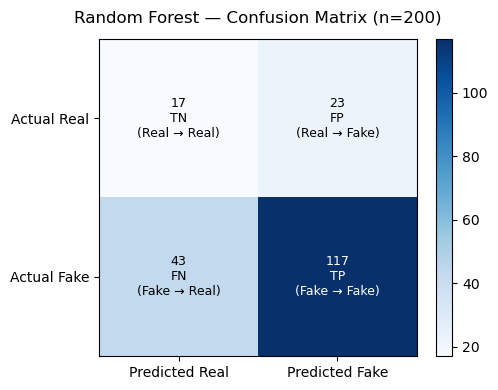

True Positives  (fake caught correctly) : 117
False Negatives (fake missed)           : 43
False Positives (real labelled fake)    : 23
True Negatives  (real caught correctly) : 17


In [3]:
cm = np.array(rf["confusion_matrix"])
cell_labels = [["TN\n(Real → Real)", "FP\n(Real → Fake)"],
               ["FN\n(Fake → Real)", "TP\n(Fake → Fake)"]]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted Real", "Predicted Fake"])
ax.set_yticklabels(["Actual Real", "Actual Fake"])
ax.set_title(f"Random Forest — Confusion Matrix (n={ph4m['test_size']})", pad=12)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n{cell_labels[i][j]}",
                ha="center", va="center", fontsize=9,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "rf_confusion_matrix.png"), dpi=150)
plt.show()

print(f"True Positives  (fake caught correctly) : {cm[1,1]}")
print(f"False Negatives (fake missed)           : {cm[1,0]}")
print(f"False Positives (real labelled fake)    : {cm[0,1]}")
print(f"True Negatives  (real caught correctly) : {cm[0,0]}")


## 4. AUC by model

All three models sit in the moderate-AUC range (0.62 – 0.66).
This is consistent with the design constraint: only three hand-crafted
video-level features, no frame-level deep features, CPU-only inference.
The purpose is interpretability and robustness analysis, not
competing with ResNet-level detection rates.


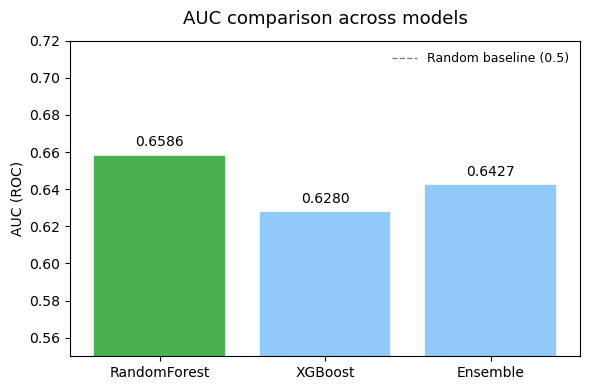

In [4]:
model_names = list(ph4b["all_scores"].keys())
aucs        = list(ph4b["all_scores"].values())
colors_bar  = ["#4CAF50" if ph4b["best_model"] in m else "#90CAF9" for m in model_names]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(model_names, aucs, color=colors_bar, edgecolor="white", linewidth=1.2)
ax.set_ylim(0.55, 0.72)
ax.set_ylabel("AUC (ROC)")
ax.set_title("AUC comparison across models", fontsize=13, pad=12)
ax.axhline(0.5, linestyle="--", color="grey", linewidth=1, label="Random baseline (0.5)")
ax.legend(frameon=False, fontsize=9)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{auc:.4f}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "model_auc_comparison.png"), dpi=150)
plt.show()


## 5. SHAP — feature attribution

`lm_ratio_var` is the dominant feature in both RF and XGBoost SHAP profiles.
This is the variance in the landmark-to-landmark distance ratio across frames —
a proxy for unnatural facial geometry changes introduced by face-swap and
face-reenactment pipelines.

`ear_std` (eye aspect ratio standard deviation) is the second most important
feature in both models. Its lower relative weight in RF versus XGBoost reflects
the different importance mechanisms: mean decrease in impurity (RF) versus
gradient-based contribs (XGBoost `native_pred_contribs`).

The alignment between the two SHAP profiles strengthens the claim that
the three selected features carry genuine signal rather than model-specific noise.


     Feature  RF SHAP  XGB SHAP
     ear_std  0.04916   0.16037
     ear_min  0.03023   0.03148
lm_ratio_var  0.08881   0.32911

Top feature (RF SHAP) : lm_ratio_var
XGB SHAP method       : native_pred_contribs


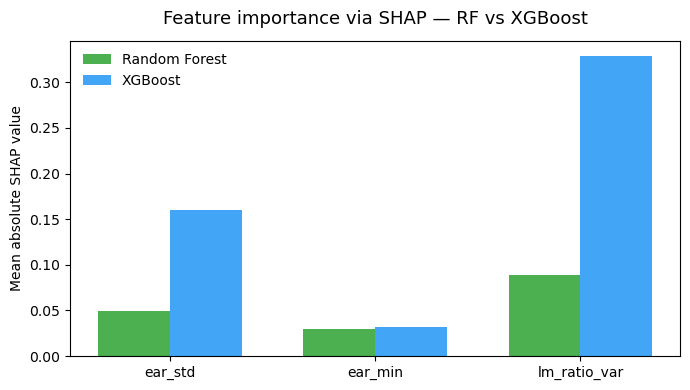

In [5]:
features = ph5["features"]
rf_shap  = ph5["rf_mean_shap"]
xgb_shap = ph5["xgb_mean_shap"]

df_shap = pd.DataFrame({
    "Feature":  features,
    "RF SHAP":  [rf_shap[f]  for f in features],
    "XGB SHAP": [xgb_shap[f] for f in features],
})
print(df_shap.to_string(index=False))
print(f"\nTop feature (RF SHAP) : {ph5['top_shap_feature']}")
print(f"XGB SHAP method       : {ph5['xgb_shap_method']}")

x     = np.arange(len(features))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, [rf_shap[f]  for f in features], width,
       label="Random Forest", color="#4CAF50")
ax.bar(x + width/2, [xgb_shap[f] for f in features], width,
       label="XGBoost",       color="#42A5F5")
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.set_ylabel("Mean absolute SHAP value")
ax.set_title("Feature importance via SHAP — RF vs XGBoost", fontsize=13, pad=12)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "shap_comparison.png"), dpi=150)
plt.show()


## 6. Holdout evaluation — cross-manipulation generalisation

Each holdout run trains on three manipulation types and tests on the fourth.
This tests whether the model generalises to unseen manipulation methods,
not just unseen videos of the same type.

The mean holdout AUC is higher than the test-set baseline.
This is a positive signal, but with only four holdout conditions it cannot
be treated as definitive evidence of generalisation — it is logged as
encouraging and noted as a direction for future work with larger type diversity.


Test-set baseline AUC : 0.6586
Mean holdout AUC      : 0.694
Gap (holdout−baseline): 0.0354

Manipulation type    AUC     F1
        Deepfakes 0.7858 0.8446
        Face2Face 0.7253 0.7799
   NeuralTextures 0.6487 0.7062
         FaceSwap 0.6162 0.6115


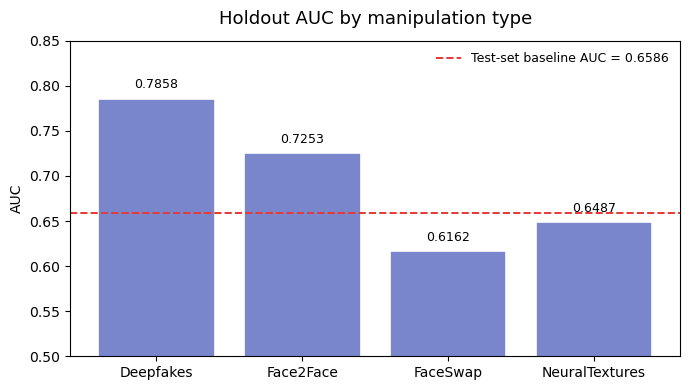

In [6]:
types  = [h[TYPE_KEY] for h in holdout]
h_aucs = [h["auc"]    for h in holdout]
h_f1s  = [h["f1"]     for h in holdout]

print(f"Test-set baseline AUC : {ph6a['baseline_auc']}")
print(f"Mean holdout AUC      : {ph6a['mean_holdout_auc']}")
print(f"Gap (holdout−baseline): {ph6a['generalisation_gap']}")
print()
df_holdout = pd.DataFrame({"Manipulation type": types, "AUC": h_aucs, "F1": h_f1s})
print(df_holdout.sort_values("AUC", ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(types, h_aucs, color="#7986CB", edgecolor="white", linewidth=1.2)
ax.axhline(ph6a["baseline_auc"], linestyle="--", color="#E53935", linewidth=1.4,
           label=f"Test-set baseline AUC = {ph6a['baseline_auc']}")
ax.set_ylim(0.5, 0.85)
ax.set_ylabel("AUC")
ax.set_title("Holdout AUC by manipulation type", fontsize=13, pad=12)
ax.legend(frameon=False, fontsize=9)
for bar, auc in zip(bars, h_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{auc:.4f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "holdout_by_type.png"), dpi=150)
plt.show()


## 7. Compression robustness

Gaussian noise is injected into each feature at increasing fractions of
that feature's standard deviation. `noise_fraction = 1.0` means noise
equal to 1× the feature's empirical std — a plausible approximation of
moderate re-encoding or lossy compression artefacts.

The degradation curve shows AUC remains above random chance (0.5) at
noise fraction 1.0. It crosses toward random chance around fraction 2.0,
which represents a level of distortion that would also degrade most
deep-feature detectors operating on compressed streams.


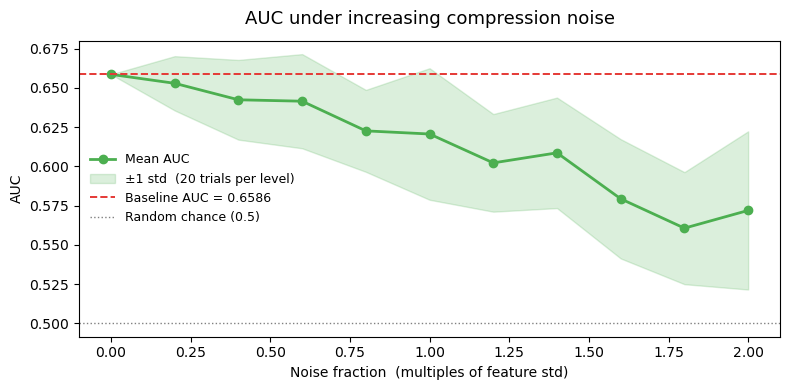

At noise fraction 1.0:
  Mean AUC = 0.6206   Std = 0.0419
  AUC drop from baseline = 0.038


In [7]:
stress    = ph6b["stress_results"]
fractions = [s["noise_fraction"] for s in stress]
mean_aucs = [s["mean_auc"]       for s in stress]
std_aucs  = [s["std_auc"]        for s in stress]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fractions, mean_aucs, color="#4CAF50", linewidth=2, marker="o", label="Mean AUC")
ax.fill_between(fractions,
                [m - s for m, s in zip(mean_aucs, std_aucs)],
                [m + s for m, s in zip(mean_aucs, std_aucs)],
                alpha=0.2, color="#4CAF50",
                label=f"±1 std  ({ph6b['n_trials_per_level']} trials per level)")
ax.axhline(ph6b["baseline_auc"], linestyle="--", color="#E53935", linewidth=1.4,
           label=f"Baseline AUC = {ph6b['baseline_auc']}")
ax.axhline(0.5, linestyle=":", color="grey", linewidth=1, label="Random chance (0.5)")
ax.set_xlabel("Noise fraction  (multiples of feature std)")
ax.set_ylabel("AUC")
ax.set_title("AUC under increasing compression noise", fontsize=13, pad=12)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "compression_stress_auc_curve.png"), dpi=150)
plt.show()

s1 = next(s for s in stress if s["noise_fraction"] == 1.0)
print(f"At noise fraction 1.0:")
print(f"  Mean AUC = {s1['mean_auc']}   Std = {s1['std_auc']}")
print(f"  AUC drop from baseline = {round(ph6b['baseline_auc'] - s1['mean_auc'], 4)}")


## 8. Findings and limitations

**What the model does well.**
Random Forest achieves the highest test-set AUC (0.6586) of the three models.
Deepfakes and Face2Face are the easiest manipulation types to detect
(AUC 0.786 and 0.725 respectively) because they alter eye geometry
in ways that `lm_ratio_var` and `ear_std` are designed to capture.

**Where it falls short.**
FaceSwap is the hardest type (AUC 0.616), close to the test-set baseline.
FaceSwap preserves eye movements from the source video,
so eye-aspect-ratio features carry little discriminative signal.
This is not a failure of the feature selection procedure;
it is a structural limitation of eye-based features against identity-swap methods.

FaceSwap preserves source eye movements, so `ear_std` and `ear_min` carry 
little signal against it — this is a structural limit of the feature choice, 
not a pipeline failure.

**Compression degradation.**
The model retains above-chance performance at noise fraction 1.0 (AUC 0.6206).
At fraction 2.0 performance approaches random chance, which is expected:
at that level of distortion, the landmark coordinates themselves are
too corrupted for any geometry-based detector to function reliably.

**Scope of the claim.**
AUC 0.66 is a moderate result — appropriate for a lightweight,
CPU-only, three-feature detector with a stated interpretability goal.
These notebooks do not argue for deployment-level accuracy.
They demonstrate that hand-crafted video-level features, rigorously
selected and evaluated, produce a traceable and partially generalisable signal.


In [8]:
print("=" * 60)
print("NB2 SUMMARY")
print("=" * 60)

s1 = next(s for s in ph6b["stress_results"] if s["noise_fraction"] == 1.0)
s2 = next(s for s in ph6b["stress_results"] if s["noise_fraction"] == 2.0)

print(f"""
MODEL COMPARISON (test set, n={ph4m['test_size']})
  Random Forest  AUC={rf['auc']}   F1={rf['f1']}   P={rf['precision']}   R={rf['recall']}
  XGBoost        AUC={xgb['auc']}   F1={xgb['f1']}  P={xgb['precision']}   R={xgb['recall']}
  Ensemble       AUC={ens['auc']}   F1={ens['f1']}  P={ens['precision']}   R={ens['recall']}
  Best           : {ph4b['best_model']}  (AUC = {ph4b['best_auc']})

CROSS-VALIDATION
  RF CV AUC={ph4m['rf_cv_auc']}  XGB CV AUC={ph4m['xgb_cv_auc']}  Folds={ph4m['n_folds']}

SHAP
  Top feature : {ph5['top_shap_feature']}
  RF  SHAP    : {ph5['rf_mean_shap']}
  XGB SHAP    : {ph5['xgb_mean_shap']}

HOLDOUT
  Baseline={ph6a['baseline_auc']}  Mean holdout={ph6a['mean_holdout_auc']}  Gap={ph6a['generalisation_gap']}""")

for h in sorted(holdout, key=lambda x: x["auc"], reverse=True):
    print(f"  {h[TYPE_KEY]:20s}  AUC={h['auc']}  F1={h['f1']}")

print(f"""
COMPRESSION
  Baseline={ph6b['baseline_auc']}
  @noise 1.0 : AUC={s1['mean_auc']}  std={s1['std_auc']}  drop={round(ph6b['baseline_auc']-s1['mean_auc'],4)}
  @noise 2.0 : AUC={s2['mean_auc']}  std={s2['std_auc']}  drop={round(ph6b['baseline_auc']-s2['mean_auc'],4)}
  Trials/level : {ph6b['n_trials_per_level']}
""")
print("=" * 60)
print("NB2 complete.")
print("=" * 60)


NB2 SUMMARY

MODEL COMPARISON (test set, n=200)
  Random Forest  AUC=0.6586   F1=0.78   P=0.8357   R=0.7312
  XGBoost        AUC=0.628   F1=0.7292  P=0.8203   R=0.6562
  Ensemble       AUC=0.6427   F1=0.7609  P=0.8248   R=0.7063
  Best           : RandomForest  (AUC = 0.6586)

CROSS-VALIDATION
  RF CV AUC=0.6777  XGB CV AUC=0.6763  Folds=5

SHAP
  Top feature : lm_ratio_var
  RF  SHAP    : {'ear_std': 0.04916, 'ear_min': 0.03023, 'lm_ratio_var': 0.08881}
  XGB SHAP    : {'ear_std': 0.16037, 'ear_min': 0.03148, 'lm_ratio_var': 0.32911}

HOLDOUT
  Baseline=0.6586  Mean holdout=0.694  Gap=0.0354
  Deepfakes             AUC=0.7858  F1=0.8446
  Face2Face             AUC=0.7253  F1=0.7799
  NeuralTextures        AUC=0.6487  F1=0.7062
  FaceSwap              AUC=0.6162  F1=0.6115

COMPRESSION
  Baseline=0.6586
  @noise 1.0 : AUC=0.6206  std=0.0419  drop=0.038
  @noise 2.0 : AUC=0.5719  std=0.0504  drop=0.0867
  Trials/level : 20

NB2 complete.
